In [1]:
import torch
from torch import nn,Tensor 
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from src.detectors.internal.linear_probe import LinearProbe

BATCH_SIZE = 32 

In [2]:
from transformers import AutoModelForCausalLM,AutoTokenizer

model = AutoModelForCausalLM.from_pretrained(
    "Qwen/Qwen3-0.6B", device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(
    "Qwen/Qwen3-0.6B", padding_side="left"
)
if torch.cuda.is_available():
    device = "cuda"
else: 
    device = "cpu"

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token


c:\Users\Ramneek\anaconda3\envs\safeguard_llm\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 311/311 [00:03<00:00, 82.92it/s] 


In [3]:
from datasets import load_dataset
from torch.utils.data import DataLoader
toxic_dataset = load_dataset("textdetox/multilingual_toxicity_dataset")
print(toxic_dataset.data["en"])
en_dataset = toxic_dataset["en"].shuffle(seed=40)

split_dataset = en_dataset.train_test_split(test_size=0.1, seed=40)
train_toxic_dataset = split_dataset["train"]
test_toxic_dataset = split_dataset["test"]
train_data = DataLoader(train_toxic_dataset, batch_size=32)
test_data = DataLoader(test_toxic_dataset, batch_size=32)
#set up llm and environment
#load dataset
#setup batched dataset
#lets start simple with a basic harmeval 
#define the linear probe
#hook into llm
#training loop with cached activation 
#compare prediction with label 


MemoryMappedTable
text: string
toxic: int64
----
text: [["The trans women reading this tweet right now is beautiful","9) uhhhh i like being lgbt a lot. i feel proud of what i have done to help others in my community","Hero Rohit Sharma love From Pakistan","As a slightly feminine top I appreciate all masc bottoms that enjoy a dude like me","Delon Love Turkey and brave Turks from Indian Muslim! In Shaa Allah we will rise again!",...,"It's 2019 we're respecting women and getting respected back.","does skin colour matter to world leaders? does what you believe matter to world leaders?","A massive thanks from a bi teen","The least we could do this Pride month is get a trans mother back to her kids. Donate and share! U (... 2 chars omitted)","is being trans valid? please retweet after voting for"],["These women are so powerful and inspiring","God is a woman and her name is Sophie Turner","Ah. I'm planning on coming out as trans (and I guess lesbian) hopefully this week. Good luck man","You d

In [4]:
print(model)

Qwen3ForCausalLM(
  (model): Qwen3Model(
    (embed_tokens): Embedding(151936, 1024)
    (layers): ModuleList(
      (0-27): 28 x Qwen3DecoderLayer(
        (self_attn): Qwen3Attention(
          (q_proj): Linear(in_features=1024, out_features=2048, bias=False)
          (k_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1024, out_features=1024, bias=False)
          (o_proj): Linear(in_features=2048, out_features=1024, bias=False)
          (q_norm): Qwen3RMSNorm((128,), eps=1e-06)
          (k_norm): Qwen3RMSNorm((128,), eps=1e-06)
        )
        (mlp): Qwen3MLP(
          (gate_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (up_proj): Linear(in_features=1024, out_features=3072, bias=False)
          (down_proj): Linear(in_features=3072, out_features=1024, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen3RMSNorm((1024,), eps=1e-06)
        (post_attention_layer

In [5]:
test = torch.rand([1,4,20])
test= torch.mean(test,dim=1)
print(test.shape)

torch.Size([1, 20])


Train Loop 1: The model trains on the final token of the prompt prefill, it learns to vector representation of toxicity in the latent space with the activation of the input prompt only. The final vector in the seq len of the prefill generation represents a vector [batch_size, dim] that has the contextual information of the entire previous sentence, meaning that we only have to train on this. 

In [6]:
def hook(module, input: Tensor, output: Tensor) -> None:
    global activation_cache 
    activation_cache = output[:, -1, :].detach().clone().to(device)

In [10]:
import torch
from tqdm.auto import tqdm
import numpy as np 
from sklearn import metrics
import matplotlib.pyplot as plt  

def train_model(layer):
    linear_probe_model = LinearProbe(in_dim=3072).to(device).bfloat16()

    forward_hook = model.model.layers[layer].mlp.act_fn.register_forward_hook(hook)
    optimizer = torch.optim.Adam(linear_probe_model.parameters(), lr=1e-3, weight_decay=1e-4)
    loss_fn = torch.nn.BCELoss()

    EPOCHS = 3
    linear_probe_model.train()
    for epoch in range(EPOCHS): 
        pbar = tqdm(train_data, desc=f"Epoch {epoch + 1}/{EPOCHS}", leave=True)
        
        for batch in pbar:
            inputs = batch["text"]
            labels = batch["toxic"].to(device).bfloat16()
            tokenized_input = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt").to(device)
            with torch.no_grad():
                outputs = model(**tokenized_input)
            scores = linear_probe_model(activation_cache)
            optimizer.zero_grad() 
            loss = loss_fn(scores.squeeze(-1), labels)
            loss.backward()
            optimizer.step()
            pbar.set_postfix(loss=f"{loss.item():.4f}")
    forward_hook.remove()
    return linear_probe_model

def eval_accuracy(linear_probe_model, layer):
    forward_hook = model.model.layers[layer].mlp.act_fn.register_forward_hook(hook)
    pbar = tqdm(test_data, leave=True)
    tp = 0
    fp = 0
    tn = 0
    fn = 0
    tp_list = []
    fp_list = []
    for batch in pbar:
        inputs = batch["text"]
        labels = batch["toxic"].to(device).bfloat16()
        tokenized_input = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**tokenized_input)
            scores = linear_probe_model.predict(activation_cache,threshold=0.53)
            scores = scores.squeeze(-1)
            tp += torch.sum(torch.logical_and(scores == 1 ,labels == 1))
            tn += torch.sum(torch.logical_and(scores == 0,labels == 0))
            fp += torch.sum(torch.logical_and(scores == 1,labels == 0))
            fn += torch.sum(torch.logical_and(scores == 0,labels == 1))
    tp_list.append(tp)
    fp_list.append(fp)
    print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
    print(fp)
    print(tn)
    print(fn)
    accuracy = (tp + tn) /( tp + fp + tn + fn)
    print(accuracy)
    forward_hook.remove()

def roc(linear_probe_model, layer):
    forward_hook = model.model.layers[layer].mlp.act_fn.register_forward_hook(hook)
    pbar = tqdm(test_data, leave=True)
    tp = 0
    fp = 0
    tn = 0
    fn = 0
    scores_full = []
    labels_full = []
    for batch in pbar:
        inputs = batch["text"]
        labels = batch["toxic"].to(device).bfloat16()
        tokenized_input = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            outputs = model(**tokenized_input)
            scores = linear_probe_model(activation_cache)
            scores_full.extend(scores.squeeze(-1).float().cpu())
            labels_full.extend(labels.float().cpu())
    fpr, tpr, thresholds = metrics.roc_curve(labels_full,scores_full)
    auroc_score = metrics.roc_auc_score(labels_full,scores_full)
    roc_auc = metrics.auc(fpr, tpr)
    display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                    name='example estimator')
    display.plot()
    plt.show()
    print("Auroc score: ", auroc_score)
    forward_hook.remove()

Layer trained: 0


100%|██████████| 16/16 [00:01<00:00,  8.96it/s]


TP: 226, FP: 32, TN: 218, FN: 24
tensor(32, device='cuda:0')
tensor(218, device='cuda:0')
tensor(24, device='cuda:0')
tensor(0.8880, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.35it/s]


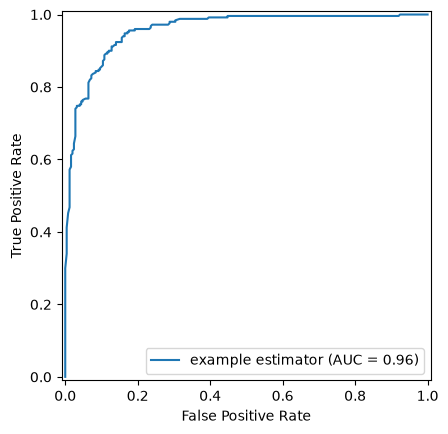

Auroc score:  0.957984
Layer trained: 1


100%|██████████| 16/16 [00:01<00:00,  9.91it/s]


TP: 226, FP: 32, TN: 218, FN: 24
tensor(32, device='cuda:0')
tensor(218, device='cuda:0')
tensor(24, device='cuda:0')
tensor(0.8880, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.37it/s]


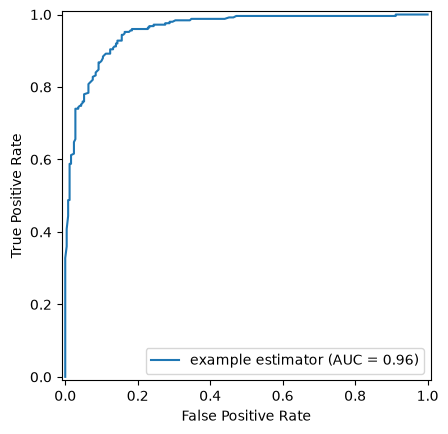

Auroc score:  0.9580239999999999
Layer trained: 2


100%|██████████| 16/16 [00:01<00:00, 10.15it/s]


TP: 226, FP: 32, TN: 218, FN: 24
tensor(32, device='cuda:0')
tensor(218, device='cuda:0')
tensor(24, device='cuda:0')
tensor(0.8880, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00, 10.47it/s]


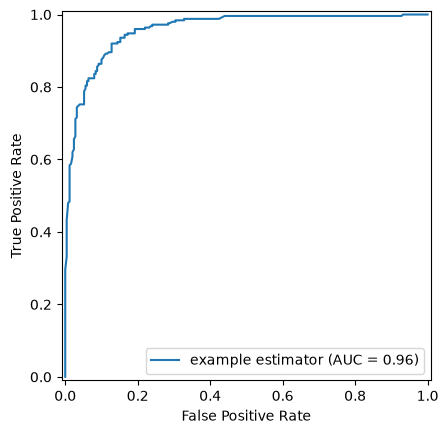

Auroc score:  0.9583119999999999
Layer trained: 3


100%|██████████| 16/16 [00:01<00:00, 10.81it/s]


TP: 224, FP: 32, TN: 218, FN: 26
tensor(32, device='cuda:0')
tensor(218, device='cuda:0')
tensor(26, device='cuda:0')
tensor(0.8840, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00, 10.40it/s]


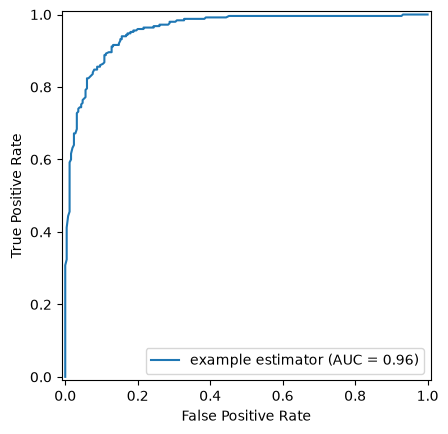

Auroc score:  0.957992
Layer trained: 4


100%|██████████| 16/16 [00:01<00:00,  9.23it/s]


TP: 225, FP: 31, TN: 219, FN: 25
tensor(31, device='cuda:0')
tensor(219, device='cuda:0')
tensor(25, device='cuda:0')
tensor(0.8880, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.06it/s]


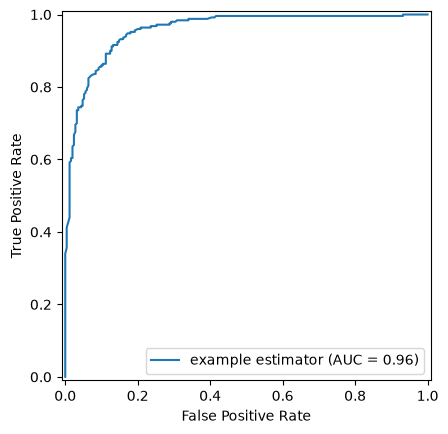

Auroc score:  0.957776
Layer trained: 5


100%|██████████| 16/16 [00:01<00:00,  9.69it/s]


TP: 226, FP: 31, TN: 219, FN: 24
tensor(31, device='cuda:0')
tensor(219, device='cuda:0')
tensor(24, device='cuda:0')
tensor(0.8900, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.32it/s]


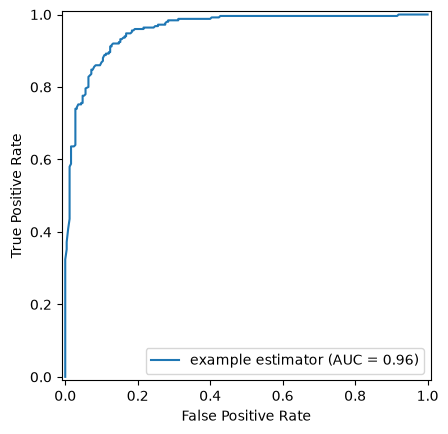

Auroc score:  0.95888
Layer trained: 6


100%|██████████| 16/16 [00:01<00:00,  9.59it/s]


TP: 225, FP: 32, TN: 218, FN: 25
tensor(32, device='cuda:0')
tensor(218, device='cuda:0')
tensor(25, device='cuda:0')
tensor(0.8860, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.12it/s]


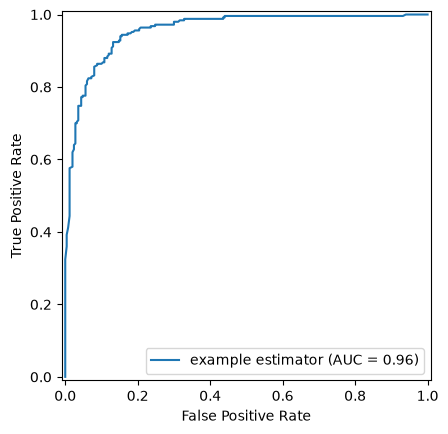

Auroc score:  0.957568
Layer trained: 7


100%|██████████| 16/16 [00:01<00:00, 10.53it/s]


TP: 224, FP: 31, TN: 219, FN: 26
tensor(31, device='cuda:0')
tensor(219, device='cuda:0')
tensor(26, device='cuda:0')
tensor(0.8860, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00, 11.00it/s]


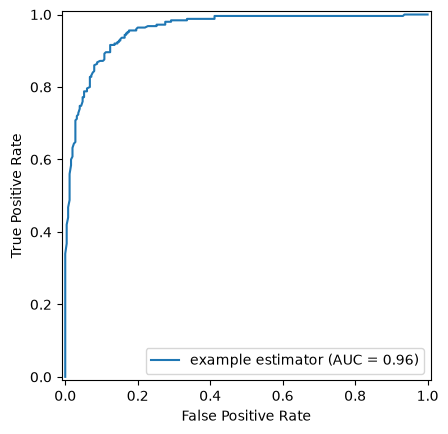

Auroc score:  0.958888
Layer trained: 8


100%|██████████| 16/16 [00:02<00:00,  7.84it/s]


TP: 225, FP: 31, TN: 219, FN: 25
tensor(31, device='cuda:0')
tensor(219, device='cuda:0')
tensor(25, device='cuda:0')
tensor(0.8880, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  8.04it/s]


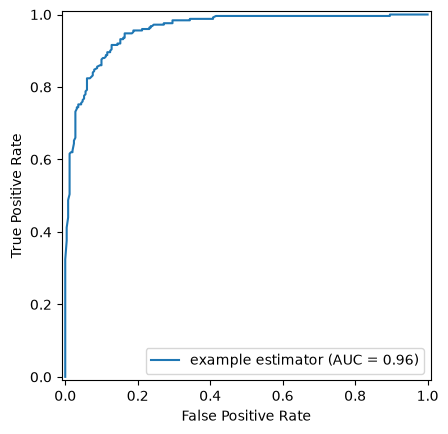

Auroc score:  0.958944
Layer trained: 9


100%|██████████| 16/16 [00:02<00:00,  7.95it/s]


TP: 226, FP: 32, TN: 218, FN: 24
tensor(32, device='cuda:0')
tensor(218, device='cuda:0')
tensor(24, device='cuda:0')
tensor(0.8880, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  8.26it/s]


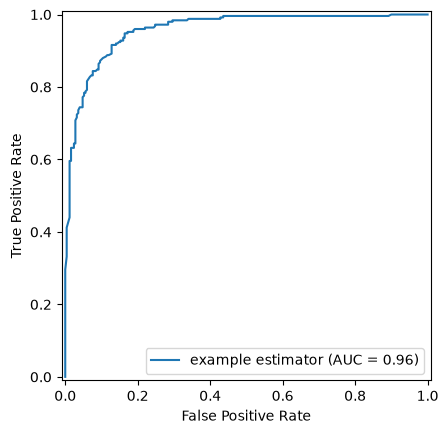

Auroc score:  0.9580799999999999
Layer trained: 10


100%|██████████| 16/16 [00:01<00:00,  8.84it/s]


TP: 225, FP: 32, TN: 218, FN: 25
tensor(32, device='cuda:0')
tensor(218, device='cuda:0')
tensor(25, device='cuda:0')
tensor(0.8860, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  8.99it/s]


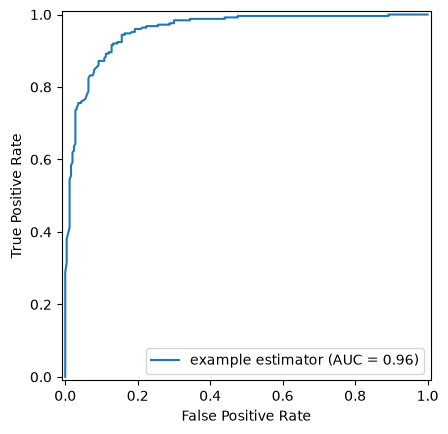

Auroc score:  0.9574
Layer trained: 11


100%|██████████| 16/16 [00:01<00:00,  9.38it/s]


TP: 225, FP: 32, TN: 218, FN: 25
tensor(32, device='cuda:0')
tensor(218, device='cuda:0')
tensor(25, device='cuda:0')
tensor(0.8860, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.45it/s]


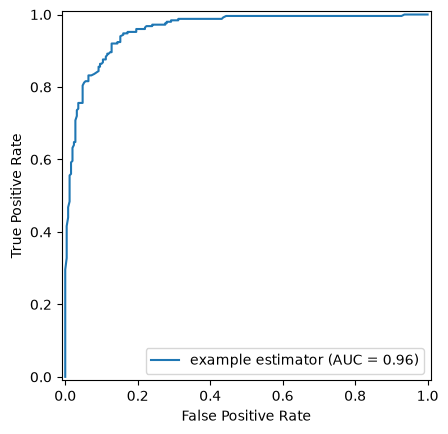

Auroc score:  0.9586559999999998
Layer trained: 12


100%|██████████| 16/16 [00:01<00:00,  9.34it/s]


TP: 225, FP: 31, TN: 219, FN: 25
tensor(31, device='cuda:0')
tensor(219, device='cuda:0')
tensor(25, device='cuda:0')
tensor(0.8880, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.32it/s]


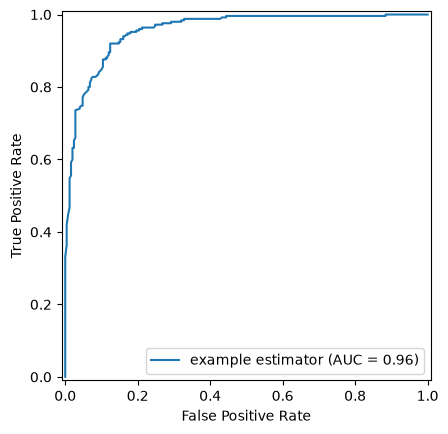

Auroc score:  0.957408
Layer trained: 13


100%|██████████| 16/16 [00:01<00:00,  9.82it/s]


TP: 226, FP: 31, TN: 219, FN: 24
tensor(31, device='cuda:0')
tensor(219, device='cuda:0')
tensor(24, device='cuda:0')
tensor(0.8900, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.59it/s]


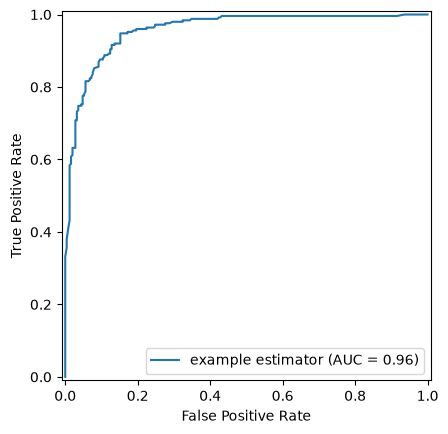

Auroc score:  0.9581999999999999
Layer trained: 14


100%|██████████| 16/16 [00:01<00:00,  9.26it/s]


TP: 221, FP: 19, TN: 231, FN: 29
tensor(19, device='cuda:0')
tensor(231, device='cuda:0')
tensor(29, device='cuda:0')
tensor(0.9040, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.35it/s]


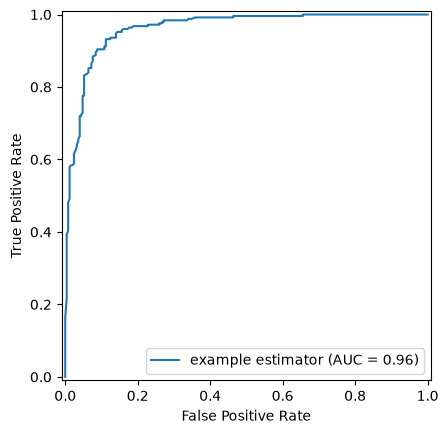

Auroc score:  0.9619519999999999
Layer trained: 15


100%|██████████| 16/16 [00:01<00:00,  9.69it/s]


TP: 215, FP: 14, TN: 236, FN: 35
tensor(14, device='cuda:0')
tensor(236, device='cuda:0')
tensor(35, device='cuda:0')
tensor(0.9020, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  8.92it/s]


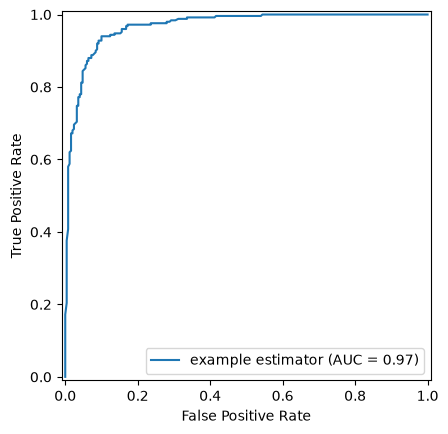

Auroc score:  0.9682079999999998
Layer trained: 16


100%|██████████| 16/16 [00:01<00:00,  9.42it/s]


TP: 187, FP: 10, TN: 240, FN: 63
tensor(10, device='cuda:0')
tensor(240, device='cuda:0')
tensor(63, device='cuda:0')
tensor(0.8540, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.10it/s]


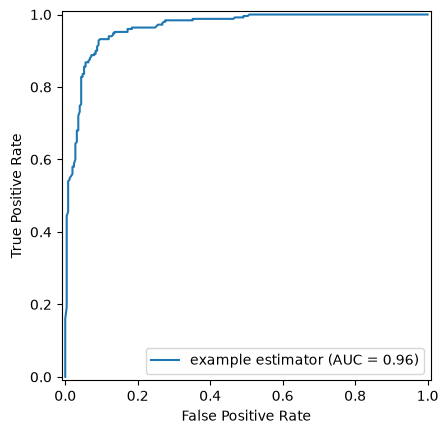

Auroc score:  0.964032
Layer trained: 17


100%|██████████| 16/16 [00:01<00:00,  9.58it/s]


TP: 211, FP: 10, TN: 240, FN: 39
tensor(10, device='cuda:0')
tensor(240, device='cuda:0')
tensor(39, device='cuda:0')
tensor(0.9020, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.63it/s]


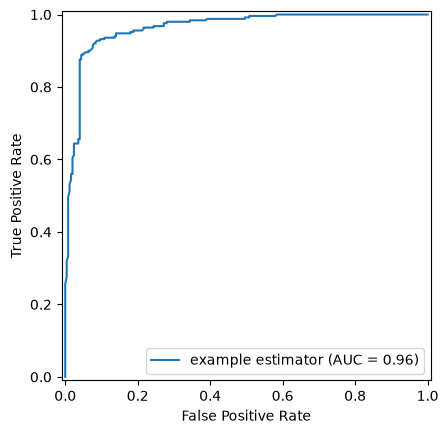

Auroc score:  0.9639279999999999
Layer trained: 18


100%|██████████| 16/16 [00:01<00:00,  9.32it/s]


TP: 214, FP: 14, TN: 236, FN: 36
tensor(14, device='cuda:0')
tensor(236, device='cuda:0')
tensor(36, device='cuda:0')
tensor(0.9000, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.24it/s]


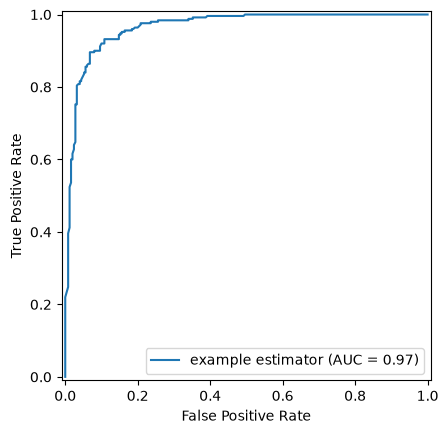

Auroc score:  0.965736
Layer trained: 19


100%|██████████| 16/16 [00:01<00:00,  9.67it/s]


TP: 207, FP: 12, TN: 238, FN: 43
tensor(12, device='cuda:0')
tensor(238, device='cuda:0')
tensor(43, device='cuda:0')
tensor(0.8900, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  9.60it/s]


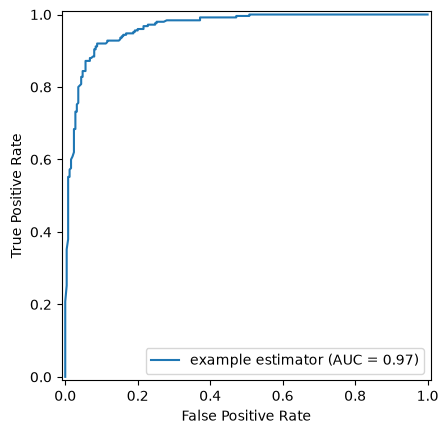

Auroc score:  0.9652639999999999
Layer trained: 20


100%|██████████| 16/16 [00:01<00:00,  9.13it/s]


TP: 219, FP: 17, TN: 233, FN: 31
tensor(17, device='cuda:0')
tensor(233, device='cuda:0')
tensor(31, device='cuda:0')
tensor(0.9040, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00,  8.72it/s]


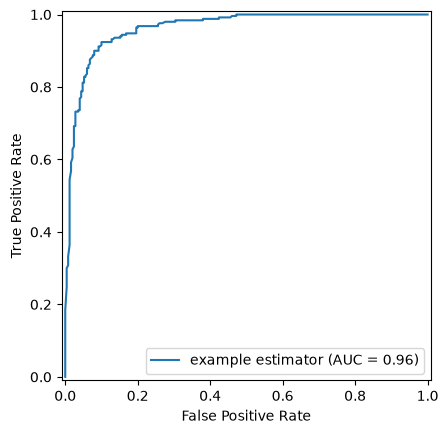

Auroc score:  0.9627680000000001
Layer trained: 21


100%|██████████| 16/16 [00:01<00:00,  9.85it/s]


TP: 215, FP: 18, TN: 232, FN: 35
tensor(18, device='cuda:0')
tensor(232, device='cuda:0')
tensor(35, device='cuda:0')
tensor(0.8940, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00, 10.25it/s]


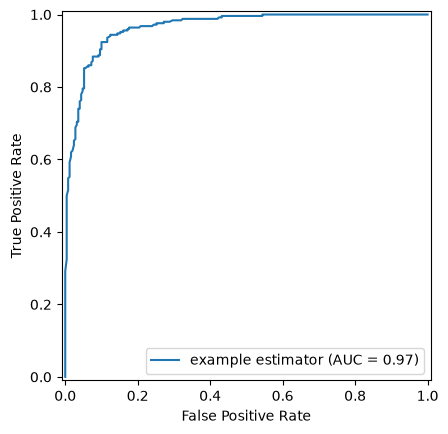

Auroc score:  0.965408
Layer trained: 22


100%|██████████| 16/16 [00:01<00:00, 10.89it/s]


TP: 223, FP: 23, TN: 227, FN: 27
tensor(23, device='cuda:0')
tensor(227, device='cuda:0')
tensor(27, device='cuda:0')
tensor(0.9000, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00, 10.90it/s]


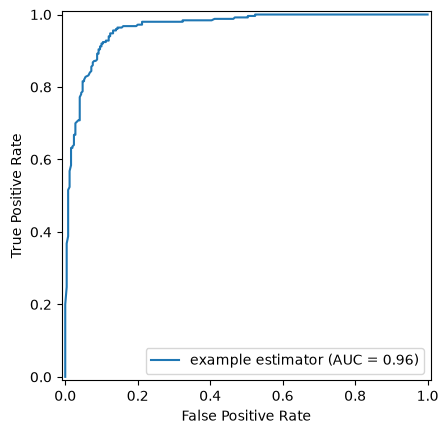

Auroc score:  0.964384
Layer trained: 23


100%|██████████| 16/16 [00:01<00:00, 10.39it/s]


TP: 225, FP: 22, TN: 228, FN: 25
tensor(22, device='cuda:0')
tensor(228, device='cuda:0')
tensor(25, device='cuda:0')
tensor(0.9060, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00, 10.70it/s]


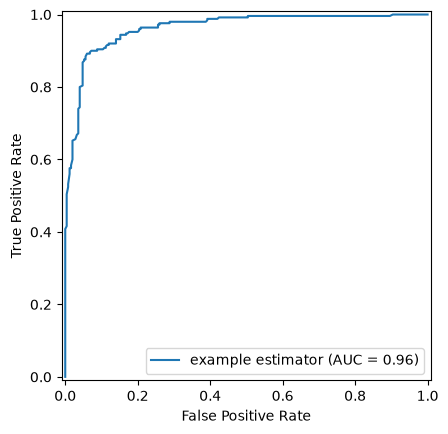

Auroc score:  0.9628079999999999
Layer trained: 24


100%|██████████| 16/16 [00:01<00:00, 10.99it/s]


TP: 229, FP: 24, TN: 226, FN: 21
tensor(24, device='cuda:0')
tensor(226, device='cuda:0')
tensor(21, device='cuda:0')
tensor(0.9100, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00, 10.94it/s]


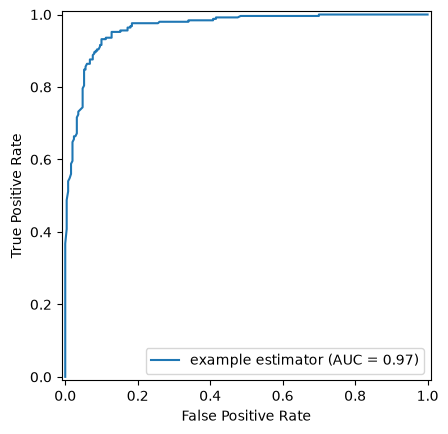

Auroc score:  0.9653120000000001
Layer trained: 25


100%|██████████| 16/16 [00:01<00:00, 11.78it/s]


TP: 226, FP: 18, TN: 232, FN: 24
tensor(18, device='cuda:0')
tensor(232, device='cuda:0')
tensor(24, device='cuda:0')
tensor(0.9160, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00, 10.67it/s]


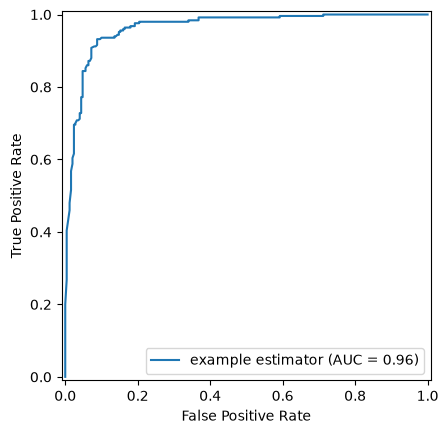

Auroc score:  0.9643999999999999
Layer trained: 26


100%|██████████| 16/16 [00:01<00:00, 12.46it/s]


TP: 224, FP: 20, TN: 230, FN: 26
tensor(20, device='cuda:0')
tensor(230, device='cuda:0')
tensor(26, device='cuda:0')
tensor(0.9080, device='cuda:0')


100%|██████████| 16/16 [00:01<00:00, 10.56it/s]


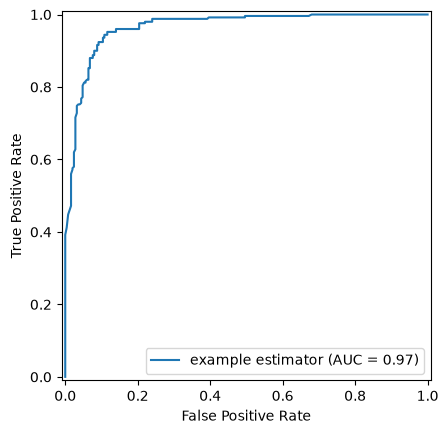

Auroc score:  0.965472


In [12]:
for layer in range(0,27):
    print(f"Layer trained: {layer}")
    linear_probe_model = train_model(layer)
    eval_accuracy(linear_probe_model, layer)
    roc(linear_probe_model, layer)

In [ ]:
torch.save(linear_probe_model.state_dict(), "model_linear.pt")

In [ ]:
linear_probe_model = LinearProbe(in_dim=3072).to(device).bfloat16()
linear_probe_model.load_state_dict(torch.load("model_linear.pt",weights_only=True))
linear_probe_model.eval()
roc(linear_probe_model,27)

LinearProbe(
  (lin): Linear(in_features=3072, out_features=1, bias=True)
  (sig): Sigmoid()
)

In [ ]:
model.model.layers[27].mlp.act_fn._forward_hooks.clear()

In [ ]:
global activation_cache_gen 
activation_cache_gen = []
def hook_2(module, input: Tensor, output: Tensor) -> None:
    activation = output[:, -1, :].detach().clone().to(device)
    scores_batch = linear_probe_model.predict(activation,threshold=0.53)
    activation_cache_gen.append(scores_batch.squeeze(-1).cpu().numpy())

def test_model_with_generation(linear_probe_model, layer):
    i = 0
    hook_multiple = model.model.layers[layer].mlp.act_fn.register_forward_hook(hook_2)
    pbar = tqdm(test_data, leave=True)
    labels_full = []
    preds_full = []
    for batch in pbar:
        if i == 100:
            break
        global activation_cache_gen
        activation_cache_gen = []
        inputs = batch["text"]
        labels = batch["toxic"].to(device).bfloat16()
        labels_full.extend(labels.float().cpu())
        tokenized_input = tokenizer(inputs, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            #autoregressively generate
            outputs = model.generate(**tokenized_input, max_new_tokens=10)
        stacked_steps = np.array(activation_cache_gen)
        batch_predictions = np.max(stacked_steps, axis=0)
        print(np.array(batch_predictions, dtype=bool))
        print("predictions:" , batch_predictions.shape)
        print("predictions:" , batch_predictions.tolist())
        preds_full.extend(batch_predictions)
        i+=1

    preds_full_np = np.array(preds_full)
    labels_full_np = np.array(labels_full)
    tp = np.sum(np.logical_and(preds_full_np == 1 ,labels_full_np == 1))
    tn = np.sum(np.logical_and(preds_full_np == 0, labels_full_np == 0))
    fp = np.sum(np.logical_and(preds_full_np == 1, labels_full_np == 0))
    fn = np.sum(np.logical_and(preds_full_np == 0, labels_full_np == 1))
    print(f"TP: {tp}, FP: {fp}, TN: {tn}, FN: {fn}")
    accuracy = (tp + tn) /( tp + fp + tn + fn)
    print(accuracy)
    hook_multiple.remove()
test_model_with_generation(linear_probe_model,27)
